Cell 1- Imports

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 40)
sns.set_theme(style='whitegrid', palette='muted')

RAW_PATH = '../data/raw/CurrentTenements.csv'
PROCESSED_PATH = '../data/processed/sites.csv'

Cell 2 - Load data: 

In [4]:
df = pd.read_csv(RAW_PATH, encoding='latin-1')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(list(df.columns))

Shape: 30,375 rows x 36 columns
['TENID', 'TYPE', 'SURVSTATUS', 'TENSTATUS', 'HOLDERCNT', 'HOLDER1', 'ADDR1', 'HOLDER2', 'ADDR2', 'HOLDER3', 'ADDR3', 'HOLDER4', 'ADDR4', 'HOLDER5', 'ADDR5', 'HOLDER6', 'ADDR6', 'HOLDER7', 'ADDR7', 'HOLDER8', 'ADDR8', 'HOLDER9', 'ADDR9', 'STARTDATE', 'STARTTIME', 'ENDDATE', 'ENDTIME', 'GRANTDATE', 'GRANTTIME', 'FMT_TENID', 'LEGAL_AREA', 'UNIT_OF_MEASURE', 'SPECIAL_IND', 'EXTRACT_DATE', 'COMBINED_REPORTING_NO', 'ALL_HOLDERS']


Cell 3 - Tenement types:

In [5]:
print(df['TYPE'].value_counts())
print(df['TENSTATUS'].value_counts())

TYPE
EXPLORATION LICENCE                       10144
MINING LEASE                               6983
PROSPECTING LICENCE                        6876
MISCELLANEOUS LICENCE                      4705
GENERAL PURPOSE LEASE                      1153
MINERAL CLAIM                               186
RETENTION LICENCE                            79
MINERAL LEASE                                75
COAL MINING LEASE                            72
TEMPORARY RESERVE                            26
MINING LEASE S.A.                            23
MINERAL LEASE S.A.                           15
GENERAL PURPOSE LEASE S.A.                   10
CHRISTMAS ISLAND MINING LEASE                 7
EXPLORATION LICENCE OFFSHORE                  6
COMMONWEALTH EXPLORATION LICENCE              4
MISCELLANEOUS LICENSE S.A.                    4
CHRISTMAS ISLAND EXPLORATION LICENCE          2
CHRISTMAS ISLAND GENERAL PURPOSE LEASE        2
LICENCE TO TREAT TAILINGS                     2
CHRISTMAS ISLAND MISCELLANEOUS LICE

Cell 4 - Filter to active mining leases: 

In [6]:
mining = df[
    (df['TYPE'] == 'MINING LEASE') &
    (df['TENSTATUS'] == 'LIVE')
].copy()

print(f'Active Mining Leases: {len(mining):,}')
print(f'Unique holders: {mining["HOLDER1"].nunique():,}')

Active Mining Leases: 6,066
Unique holders: 1,053


Cell 5 - Top holders chart:

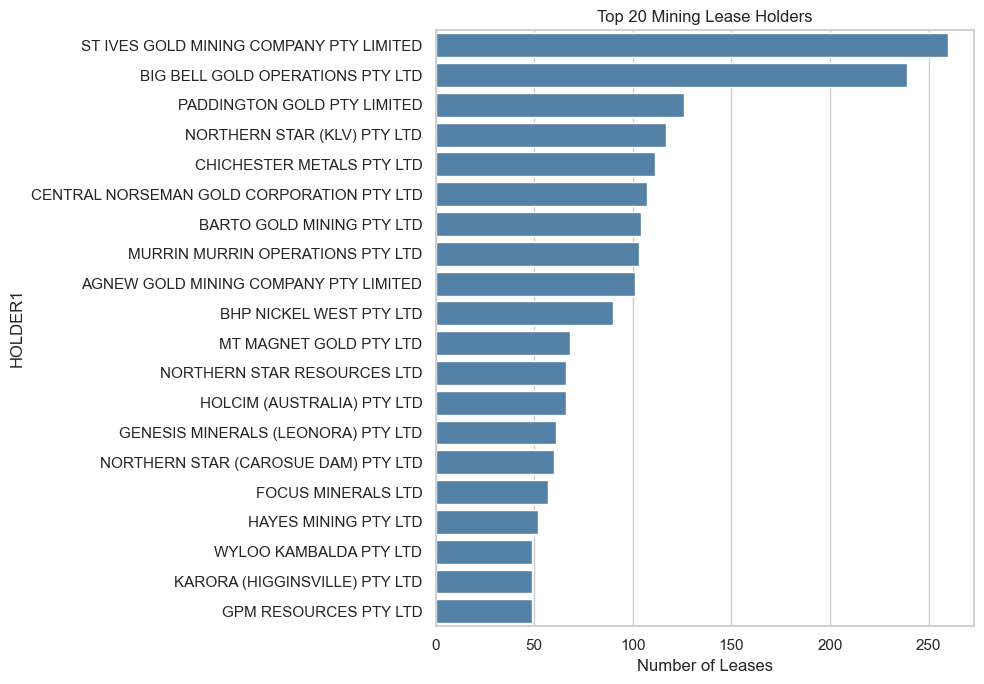

In [7]:
top_holders = mining['HOLDER1'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=top_holders.values, y=top_holders.index, ax=ax, color='steelblue')
ax.set_title('Top 20 Mining Lease Holders')
ax.set_xlabel('Number of Leases')
plt.tight_layout()
plt.show()

Cell 6 — Infer commodity:

In [8]:
def infer_commodity(name):
    name = str(name).upper()
    if any(k in name for k in ['GOLD', 'KALGOORLIE', 'NORSEMAN', 'PADDINGTON']):
        return 'Gold'
    elif any(k in name for k in ['NICKEL', 'NICKEL WEST', 'MURRIN']):
        return 'Nickel'
    elif any(k in name for k in ['LITHIUM', 'TALISON']):
        return 'Lithium'
    elif any(k in name for k in ['PILBARA', 'FMG', 'FORTESCUE', 'CHICHESTER']):
        return 'Iron Ore'
    elif any(k in name for k in ['COPPER', 'SANDFIRE']):
        return 'Copper'
    elif any(k in name for k in ['COAL', 'GRIFFIN']):
        return 'Coal'
    else:
        return 'Other'

mining['COMMODITY'] = mining['HOLDER1'].apply(infer_commodity)
print(mining['COMMODITY'].value_counts())

COMMODITY
Other       4112
Gold        1426
Nickel       259
Iron Ore     200
Copper        27
Lithium       24
Coal          18
Name: count, dtype: int64


Cell 7 — Infer region:

In [9]:
def infer_region(name, commodity):
    name = str(name).upper()
    if any(k in name for k in ['PILBARA', 'FMG', 'FORTESCUE', 'CHICHESTER']):
        return 'Pilbara'
    elif any(k in name for k in ['KALGOORLIE', 'KAMBALDA', 'NORSEMAN', 'LEONORA',
                                  'AGNEW', 'MURRIN', 'BIG BELL', 'PADDINGTON',
                                  'CAROSUE', 'HIGGINSVILLE', 'ST IVES']):
        return 'Goldfields'
    elif any(k in name for k in ['MT MAGNET', 'KARARA', 'MIDWEST']):
        return 'Midwest'
    elif any(k in name for k in ['KIMBERLEY', 'ARGYLE']):
        return 'Kimberley'
    elif any(k in name for k in ['TALISON', 'GREENBUSHES']):
        return 'South West'
    elif commodity == 'Iron Ore':
        return 'Pilbara'
    elif commodity in ['Gold', 'Nickel']:
        return 'Goldfields'
    else:
        return 'Other WA'

mining['REGION'] = mining.apply(
    lambda r: infer_region(r['HOLDER1'], r['COMMODITY']), axis=1
)
print(mining['REGION'].value_counts())

REGION
Other WA      3864
Goldfields    1830
Pilbara        212
Midwest        109
Kimberley       38
South West      13
Name: count, dtype: int64


Cell 8 — Build sites table:

In [10]:
mining['GRANTDATE'] = pd.to_datetime(mining['GRANTDATE'], format='%Y%m%d', errors='coerce')
mining['STARTDATE'] = pd.to_datetime(mining['STARTDATE'], format='%Y%m%d', errors='coerce')

sites = (
    mining.groupby(['HOLDER1', 'COMMODITY', 'REGION'])
    .agg(
        lease_count=('TENID', 'count'),
        total_area_ha=('LEGAL_AREA', 'sum'),
        first_grant_date=('GRANTDATE', 'min')
    )
    .reset_index()
    .rename(columns={'HOLDER1': 'operator_name'})
)

sites.insert(0, 'site_id', range(1, len(sites) + 1))
sites['total_area_ha'] = sites['total_area_ha'].round(2)

print(f'Sites: {len(sites):,}')
sites.head(10)

Sites: 1,053


,site_id,operator_name,COMMODITY,REGION,lease_count,total_area_ha,first_grant_date
0,1,14 MILE WELL GOLD PTY LTD,Gold,Goldfields,2,61.56,2015-09-24
1,2,4METALS RESOURCES PTY LTD,Other,Other WA,1,199.17,2025-04-03
2,3,79 EXPLORATION PTY LTD,Other,Other WA,2,909.60,2026-04-17
3,4,A.C.N. 643 478 371 PTY LTD,Other,Other WA,1,362.90,1994-04-28
4,5,A.C.N. 665 883 509 PTY LTD,Other,Other WA,1,866.40,1996-08-15
5,6,ABALONE (WA) PTY LTD,Other,Other WA,5,107.84,1983-05-18
6,7,ABRA MINING PTY LIMITED,Other,Other WA,1,999.80,2000-12-22
7,8,AC MINERALS PTY LTD,Other,Other WA,2,2500.33,2023-01-11
8,9,ACCELERATE RESOURCES LIMITED,Other,Other WA,2,104.32,1991-08-20
9,10,ACCENT RESOURCES NL,Other,Other WA,3,2323.55,1989-09-28


Cell 9 — Export:

In [11]:
import os
os.makedirs('../data/processed', exist_ok=True)
sites.to_csv(PROCESSED_PATH, index=False)
print(f'Saved to {PROCESSED_PATH}')

Saved to ../data/processed/sites.csv
